<a href="https://colab.research.google.com/github/MRazaRashid/SolvedMLNotebooks/blob/main/LASSO_RIDGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### `Task` Train a Lasso And Ridge Regression model on Boston House Price Datset. And also show how it reduces overfitting in compare to normal Linear regression model.

Data set Link - https://www.kaggle.com/datasets/altavish/boston-housing-dataset

DataSet description:
```
ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS: proportion of non-retail business acres per town
CHAS: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX: nitric oxides concentration (parts per 10 million)
RM: average number of rooms per dwelling
AGE: proportion of owner-occupied units built prior to 1940
DIS: weighted distances to ﬁve Boston employment centers
RAD: index of accessibility to radial highways
TAX: full-value property-tax rate per $10,000
PTRATIO: pupil-teacher ratio by town 12. B: 1000(Bk−0.63)2 where Bk is the proportion of blacks by town 13. LSTAT: % lower status of the population
MEDV: Median value of owner-occupied homes in $1000s (Target)
```

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import r2_score, mean_squared_error,root_mean_squared_error
from sklearn.impute import SimpleImputer

In [21]:
df = pd.read_csv("HousingData.csv")

In [22]:
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())

(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [23]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [24]:
X = df.drop(columns=TARGET)
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [25]:
lin = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)
lin.fit(X_train, y_train)

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('polynomialfeatures', PolynomialFeatures(include_bias=False)),
                ('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [26]:
train_pred = lin.predict(X_train)
test_pred = lin.predict(X_test)

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))
print("Train RMSE:", root_mean_squared_error(y_train, train_pred))
print("Test RMSE:", root_mean_squared_error(y_test, test_pred))

Train R2: 0.936468085364957
Test R2: 0.47774247741358156
Train RMSE: 2.3630985598201515
Test RMSE: 6.238190818780656


In [29]:
ridge = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Ridge(alpha=10)
)
ridge.fit(X_train, y_train)

print("Train R2:", r2_score(y_train, ridge.predict(X_train)))
print("Test R2:", r2_score(y_test, ridge.predict(X_test)))

Train R2: 0.8607358655751707
Test R2: 0.8303256570697191


In [31]:
lasso = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    Lasso(alpha=0.1, max_iter=50000)
)
lasso.fit(X_train, y_train)

print("Train R2:", r2_score(y_train, lasso.predict(X_train)))
print("Test R2:", r2_score(y_test, lasso.predict(X_test)))

Train R2: 0.8229213319003225
Test R2: 0.8071971341910831


In [32]:
results = {"Linear": lin, "Ridge": ridge, "Lasso": lasso}

summary = []
for name, model in results.items():
    tr = r2_score(y_train, model.predict(X_train))
    te = r2_score(y_test, model.predict(X_test))
    coefs = model[-1].coef_          # last pipeline step — the fitted regressor
    nonzero = int(np.sum(np.abs(coefs) > 1e-8))
    summary.append({
        "Model": name, "Train R2": tr, "Test R2": te,
        "Gap": tr - te, "Non-zero coefs": nonzero, "Total coefs": len(coefs)
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

    Model  Train R2   Test R2       Gap  Non-zero coefs  Total coefs
0  Linear  0.936468  0.477742  0.458726             104          104
1   Ridge  0.860736  0.830326  0.030410             104          104
2   Lasso  0.822921  0.807197  0.015724              24          104


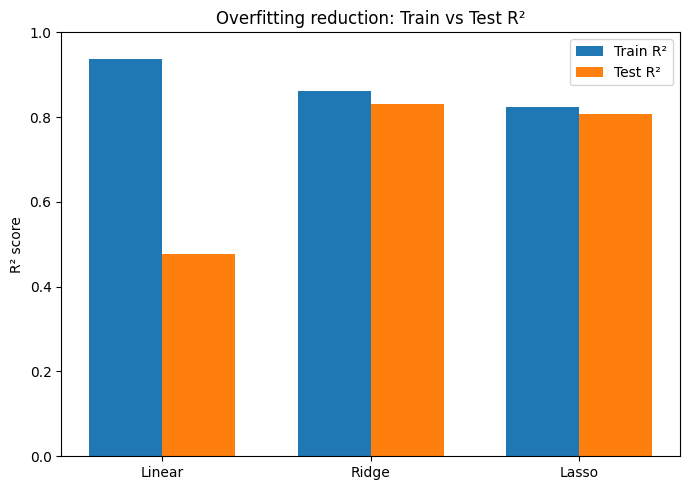

In [33]:
x = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, summary_df["Train R2"], width, label="Train R²")
ax.bar(x + width/2, summary_df["Test R2"], width, label="Test R²")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["Model"])
ax.set_ylabel("R² score")
ax.set_ylim(0, 1)
ax.set_title("Overfitting reduction: Train vs Test R²")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
from sklearn.linear_model import RidgeCV, LassoCV

alphas = np.logspace(-3, 3, 50)   # 0.001 to 1000, 50 log-spaced values

ridge_cv = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=alphas, cv=5)
)
ridge_cv.fit(X_train, y_train)

lasso_cv = make_pipeline(
    SimpleImputer(strategy="median"),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LassoCV(cv=5, max_iter=50000, random_state=42)
)
lasso_cv.fit(X_train, y_train)

print("Ridge best alpha:", ridge_cv[-1].alpha_)
print("Lasso best alpha:", lasso_cv[-1].alpha_)
print("Ridge CV  train R2:", r2_score(y_train, ridge_cv.predict(X_train)),
      " test R2:", r2_score(y_test, ridge_cv.predict(X_test)))
print("Lasso CV  train R2:", r2_score(y_train, lasso_cv.predict(X_train)),
      " test R2:", r2_score(y_test, lasso_cv.predict(X_test)))

Ridge best alpha: 0.15998587196060574
Lasso best alpha: 0.00696402718237172
Ridge CV  train R2: 0.9284431673468403  test R2: 0.6270027585449727
Lasso CV  train R2: 0.9160822137971308  test R2: 0.6489108078899323


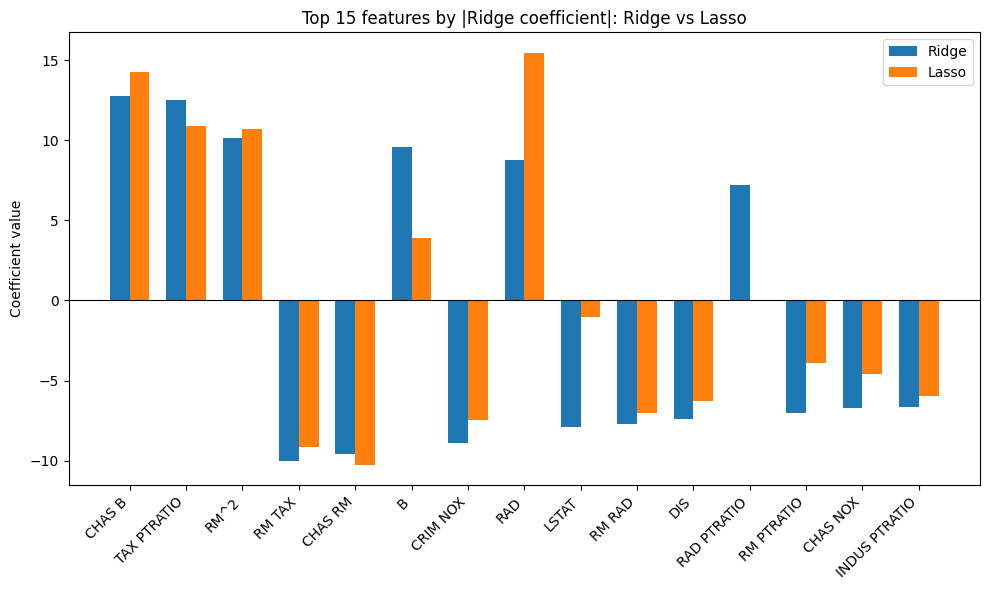

In [35]:
feature_names = ridge_cv.named_steps["polynomialfeatures"].get_feature_names_out(X.columns)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "ridge": ridge_cv[-1].coef_,
    "lasso": lasso_cv[-1].coef_
})
coef_df["ridge_abs"] = coef_df["ridge"].abs()
top = coef_df.sort_values("ridge_abs", ascending=False).head(15)

x = np.arange(len(top))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, top["ridge"], width, label="Ridge")
ax.bar(x + width/2, top["lasso"], width, label="Lasso")
ax.set_xticks(x)
ax.set_xticklabels(top["feature"], rotation=45, ha="right")
ax.set_ylabel("Coefficient value")
ax.set_title("Top 15 features by |Ridge coefficient|: Ridge vs Lasso")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

### `Task` perform Lasso and Ridge in Wine Quality dataset and show how it's different from Linear Regression.

Data link : https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv



In [27]:
# Loading Wine dataset
import pandas as pd
wine_data_path = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQDVwxneOKOaJL13QMhkAhYrgWlH1tICY7RacUnj_lL8m9uUWaaUf3p7bScNyh_D2Rvt7nc1q11adSy/pub?gid=647503637&single=true&output=csv"
data = pd.read_csv(wine_data_path)

In [28]:
# Your Code goes here